In [1]:
import numpy as np
import jax.numpy as jnp
import diffrax
import jax
from jax import grad, jacrev
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.integrate import solve_ivp
from scipy.integrate import ode
from time import time

jax.config.update("jax_platform_name", "cpu")
jax.config.update("jax_enable_x64", True)
plt.rcParams.update({'font.size':10})

In [2]:
m = open('ERK_model.net','r')
mLines = m.readlines()

for i in range(len(mLines)):
    
    if ('begin' in mLines[i])&('parameters' in mLines[i]):
        parInit = i+1
        
    if ('end' in mLines[i])&('parameters' in mLines[i]):
        parEnd = i
    
    if ('begin' in mLines[i])&('reactions' in mLines[i]):
        reactInit = i+1
        
    if ('end' in mLines[i])&('reactions' in mLines[i]):
        reactEnd = i
        
    if ('begin' in mLines[i])&('species' in mLines[i]):
        speciesInit = i+1
        
    if ('end' in mLines[i])&('species' in mLines[i]):
        speciesEnd = i    
    
parLines = mLines[parInit:parEnd]
lines = mLines[reactInit:reactEnd]  
speciesLines = mLines[speciesInit:speciesEnd]  
numPars = len(parLines)

In [3]:
# parameter block

parListString=''

for parID in range(len(parLines)):
    
    parLines[parID]=parLines[parID].replace("^","**")
    
    separated= parLines[parID].split(' ')
    
    for index in range(len(separated)-1,-1,-1):
        
        if len(separated[index])==0:
            del separated[index]
    
    parListString += separated[1]+', '
    
    #print(f'Parameter {parID} named {separated[1]} := {separated[2]}')
    exec(separated[1]+'='+separated[2])
    print(separated[1]+'='+separated[2])


packing = 'par=['+parListString+']'
unpacking = parListString+'=par'

exec(packing)
print(packing)

EGF=20
ERKpp_SOS1_FB=1.0
ERKpp_MEK_FB=1.0
ERKpp_RAF1_FB=1.0
lamb=1.0
RAS_t0_active=0
EGFR_tot=3e5*lamb
RAS_tot=6e4*lamb
SOS_tot=1e5*lamb
RasGAP_tot=6e3*lamb
RAF_tot=5e5*lamb
MEK_tot=2e5*lamb
ERK_tot=3e6*lamb
EKAR3_tot=1e6*lamb
ERKTR_tot=1e6*lamb
a1=5e-5*EGF
d1=1e-2
b1=1e-5/lamb
u1a=1e-2
u1b=1e+2
b2a=1e-6/lamb
u2a=1
b2b=1e-7/lamb
u2b=1
k2a=1e-4/lamb
k2b=1e-5/lamb
b3=1e-5/lamb
u3=1e-2
k3=1e+2
a2=1e-7/lamb
d2=1e-2
p1=1e-7/lamb
q1=1e-2
p2=3e-6/lamb
q2=1e-2
p3=(3e-9/lamb)*ERKpp_SOS1_FB
q3=3e-4
p4=(6e-10/lamb)*ERKpp_MEK_FB
q4=3e-4
q5=1e+2
p6=(6e-10/lamb)*ERKpp_RAF1_FB
q6=3e-4
a0_ekar3=3e-9/lamb
d0_ekar3=1e-3
a0_erktr=1e-9/lamb
d0_erktr=2e-3
_InitialConc1=RAS_tot*(1-RAS_t0_active)
_InitialConc2=RAS_tot*RAS_t0_active
_rateLaw1=p1*2
_rateLaw2=q1*2
_rateLaw3=p2*2
_rateLaw4=q2*2
_rateLaw5=p3*4
_rateLaw6=p3*3
_rateLaw7=p3*2
_rateLaw8=q3*2
_rateLaw9=q3*3
_rateLaw10=q3*4
_rateLaw11=q5*2
par=[EGF, ERKpp_SOS1_FB, ERKpp_MEK_FB, ERKpp_RAF1_FB, lamb, RAS_t0_active, EGFR_tot, RAS_tot, SOS_tot, RasGAP_tot,

In [4]:
numSpecies = len(speciesLines)
IC= jnp.zeros((numSpecies,))

for speciesID in range(numSpecies):
    
    separated= speciesLines[speciesID].split(' ')
    
    for index in range(len(separated)-1,-1,-1):
        
        if len(separated[index])==0:
            del separated[index]

    exec('IC=IC.at[speciesID].set('+separated[2]+')')

In [5]:
reactants = np.zeros((len(lines),10))
products = np.zeros((len(lines),10))
rates = jnp.zeros((len(lines), ))

for reactionID in range(len(lines)):
    
    separated= lines[reactionID].split(' ')
    
    for index in range(len(separated)-1,-1,-1):
        
        if len(separated[index])==0:
            del separated[index]
            
    reactantSet = separated[1].split(',')
    reactants[reactionID][0]=len(reactantSet)
    
    for reactantID in range(len(reactantSet)):
        reactants[reactionID][reactantID+1] = int(reactantSet[reactantID])-1
        
    productSet = separated[2].split(',')
    products[reactionID][0]=len(productSet)
    
    for productID in range(len(productSet)):
        products[reactionID][productID+1] = int(productSet[productID])-1

    exec( 'rates=rates.at[reactionID].set('+separated[3]+')')
    print( f'rates=rates.at[{reactionID}].set('+separated[3]+')' )

rates=rates.at[0].set(a1)
rates=rates.at[1].set(b3)
rates=rates.at[2].set(a2)
rates=rates.at[3].set(d1)
rates=rates.at[4].set(b1)
rates=rates.at[5].set(k3)
rates=rates.at[6].set(d2)
rates=rates.at[7].set(_rateLaw1)
rates=rates.at[8].set(d1)
rates=rates.at[9].set(u1a)
rates=rates.at[10].set(b2a)
rates=rates.at[11].set(b2b)
rates=rates.at[12].set(u3)
rates=rates.at[13].set(p1)
rates=rates.at[14].set(q1)
rates=rates.at[15].set(a1)
rates=rates.at[16].set(d1)
rates=rates.at[17].set(d1)
rates=rates.at[18].set(u1b)
rates=rates.at[19].set(b2a)
rates=rates.at[20].set(u2a)
rates=rates.at[21].set(b2b)
rates=rates.at[22].set(u2b)
rates=rates.at[23].set(k2a)
rates=rates.at[24].set(k2b)
rates=rates.at[25].set(_rateLaw2)
rates=rates.at[26].set(_rateLaw3)
rates=rates.at[27].set(a1)
rates=rates.at[28].set(a1)
rates=rates.at[29].set(u2a)
rates=rates.at[30].set(u2b)
rates=rates.at[31].set(k2a)
rates=rates.at[32].set(k2b)
rates=rates.at[33].set(p2)
rates=rates.at[34].set(q2)
rates=rates.at[35].set(_rateLa

In [6]:
# dimeriztion needs extra care

numReactions = len(rates)

minNum = 20
dimerizationIndex = np.zeros((numReactions,))

for i in range(len(rates)):

    if minNum > reactants[i][0]:
        
        minNum = reactants[i][0]
    
    if (reactants[i][0]==2)&(reactants[i][1]==reactants[i][2]):
        print('reaction ID='+str(i)+' is dimerization!!')
        print(asarray(reactants[i])+1)
        print(asarray(products[i])+1)
        
        dimerizationIndex[i]=1.

reactants=reactants.astype('int')
products=products.astype('int')
        

In [7]:
rates

Array([1.0e-03, 1.0e-05, 1.0e-07, 1.0e-02, 1.0e-05, 1.0e+02, 1.0e-02,
       2.0e-07, 1.0e-02, 1.0e-02, 1.0e-06, 1.0e-07, 1.0e-02, 1.0e-07,
       1.0e-02, 1.0e-03, 1.0e-02, 1.0e-02, 1.0e+02, 1.0e-06, 1.0e+00,
       1.0e-07, 1.0e+00, 1.0e-04, 1.0e-05, 2.0e-02, 6.0e-06, 1.0e-03,
       1.0e-03, 1.0e+00, 1.0e+00, 1.0e-04, 1.0e-05, 3.0e-06, 1.0e-02,
       2.0e-02, 1.2e-08, 6.0e-10, 6.0e-10, 6.0e-10, 6.0e-10, 6.0e-10,
       3.0e-09, 1.0e-09, 2.0e-07, 1.0e-07, 2.0e-02, 1.0e-02, 6.0e-06,
       3.0e-06, 9.0e-09, 3.0e-04, 3.0e-04, 3.0e-04, 3.0e-04, 2.0e+02,
       1.0e+02, 3.0e-04, 1.0e-03, 2.0e-03, 6.0e-09, 6.0e-04, 3.0e-09,
       9.0e-04, 1.2e-03], dtype=float64)

In [8]:
@jax.jit
def RHS(t,X,rates):

    dx = jnp.zeros((numSpecies,))
    
    for i in range(numReactions):
        
        flux = rates[i]
        
        for j in range(1, reactants[i][0]+1):
            
            flux = flux*X[reactants[i][j]]
        
        for j in range(1, reactants[i][0]+1):

            dx = dx.at[ reactants[i][j] ].add(-flux)
            
        for j in range(1, products[i][0]+1):

            dx = dx.at[ products[i][j] ].add(+flux)

    return dx

# Let's pass 1 parameter ERKpp_SOS1_FB as the free parameter 
<font color=red> **Note that we are running a very short time, $t\in (0,20)$.** </color>

In [11]:
tSpan = np.linspace(0,8640.0,11)
tol=1e-6

@jax.jit
def xt(ERKpp_SOS1_FB):
    
    EGF=20
    #ERKpp_SOS1_FB=ERKpp_SOS1_FB
    ERKpp_MEK_FB=1.0
    ERKpp_RAF1_FB=1.0
    lamb=1.0
    RAS_t0_active=0
    EGFR_tot=3e5*lamb
    RAS_tot=6e4*lamb
    SOS_tot=1e5*lamb
    RasGAP_tot=6e3*lamb
    RAF_tot=5e5*lamb
    MEK_tot=2e5*lamb
    ERK_tot=3e6*lamb
    EKAR3_tot=1e6*lamb
    ERKTR_tot=1e6*lamb
    a1=5e-5*EGF
    d1=1e-2
    b1=1e-5/lamb
    u1a=1e-2
    u1b=1e+2
    b2a=1e-6/lamb
    u2a=1
    b2b=1e-7/lamb
    u2b=1
    k2a=1e-4/lamb
    k2b=1e-5/lamb
    b3=1e-5/lamb
    u3=1e-2
    k3=1e+2
    a2=1e-7/lamb
    d2=1e-2
    p1=1e-7/lamb
    q1=1e-2
    p2=3e-6/lamb
    q2=1e-2
    p3=(3e-9/lamb)*ERKpp_SOS1_FB
    q3=3e-4
    p4=(6e-10/lamb)*ERKpp_MEK_FB
    q4=3e-4
    q5=1e+2
    p6=(6e-10/lamb)*ERKpp_RAF1_FB
    q6=3e-4
    a0_ekar3=3e-9/lamb
    d0_ekar3=1e-3
    a0_erktr=1e-9/lamb
    d0_erktr=2e-3
    _InitialConc1=RAS_tot*(1-RAS_t0_active)
    _InitialConc2=RAS_tot*RAS_t0_active
    _rateLaw1=p1*2
    _rateLaw2=q1*2
    _rateLaw3=p2*2
    _rateLaw4=q2*2
    _rateLaw5=p3*4
    _rateLaw6=p3*3
    _rateLaw7=p3*2
    _rateLaw8=q3*2
    _rateLaw9=q3*3
    _rateLaw10=q3*4
    _rateLaw11=q5*2

    par=[EGF, ERKpp_SOS1_FB, ERKpp_MEK_FB, ERKpp_RAF1_FB, lamb, RAS_t0_active, EGFR_tot, RAS_tot, SOS_tot, RasGAP_tot, RAF_tot, MEK_tot, ERK_tot, EKAR3_tot, ERKTR_tot, a1, d1, b1, u1a, u1b, b2a, u2a, b2b, u2b, k2a, k2b, b3, u3, k3, a2, d2, p1, q1, p2, q2, p3, q3, p4, q4, q5, p6, q6, a0_ekar3, d0_ekar3, a0_erktr, d0_erktr, _InitialConc1, _InitialConc2, _rateLaw1, _rateLaw2, _rateLaw3, _rateLaw4, _rateLaw5, _rateLaw6, _rateLaw7, _rateLaw8, _rateLaw9, _rateLaw10, _rateLaw11, ]

    rates = jnp.zeros((len(lines), ))
    
    rates=rates.at[0].set(a1)
    rates=rates.at[1].set(b3)
    rates=rates.at[2].set(a2)
    rates=rates.at[3].set(d1)
    rates=rates.at[4].set(b1)
    rates=rates.at[5].set(k3)
    rates=rates.at[6].set(d2)
    rates=rates.at[7].set(_rateLaw1)
    rates=rates.at[8].set(d1)
    rates=rates.at[9].set(u1a)
    rates=rates.at[10].set(b2a)
    rates=rates.at[11].set(b2b)
    rates=rates.at[12].set(u3)
    rates=rates.at[13].set(p1)
    rates=rates.at[14].set(q1)
    rates=rates.at[15].set(a1)
    rates=rates.at[16].set(d1)
    rates=rates.at[17].set(d1)
    rates=rates.at[18].set(u1b)
    rates=rates.at[19].set(b2a)
    rates=rates.at[20].set(u2a)
    rates=rates.at[21].set(b2b)
    rates=rates.at[22].set(u2b)
    rates=rates.at[23].set(k2a)
    rates=rates.at[24].set(k2b)
    rates=rates.at[25].set(_rateLaw2)
    rates=rates.at[26].set(_rateLaw3)
    rates=rates.at[27].set(a1)
    rates=rates.at[28].set(a1)
    rates=rates.at[29].set(u2a)
    rates=rates.at[30].set(u2b)
    rates=rates.at[31].set(k2a)
    rates=rates.at[32].set(k2b)
    rates=rates.at[33].set(p2)
    rates=rates.at[34].set(q2)
    rates=rates.at[35].set(_rateLaw4)
    rates=rates.at[36].set(_rateLaw5)
    rates=rates.at[37].set(p4)
    rates=rates.at[38].set(p4)
    rates=rates.at[39].set(p4)
    rates=rates.at[40].set(p6)
    rates=rates.at[41].set(p6)
    rates=rates.at[42].set(a0_ekar3)
    rates=rates.at[43].set(a0_erktr)
    rates=rates.at[44].set(_rateLaw1)
    rates=rates.at[45].set(p1)
    rates=rates.at[46].set(_rateLaw2)
    rates=rates.at[47].set(q1)
    rates=rates.at[48].set(_rateLaw3)
    rates=rates.at[49].set(p2)
    rates=rates.at[50].set(_rateLaw6)
    rates=rates.at[51].set(q3)
    rates=rates.at[52].set(q4)
    rates=rates.at[53].set(q4)
    rates=rates.at[54].set(q4)
    rates=rates.at[55].set(_rateLaw11)
    rates=rates.at[56].set(q5)
    rates=rates.at[57].set(q6)
    rates=rates.at[58].set(d0_ekar3)
    rates=rates.at[59].set(d0_erktr)
    rates=rates.at[60].set(_rateLaw7)
    rates=rates.at[61].set(_rateLaw8)
    rates=rates.at[62].set(p3)
    rates=rates.at[63].set(_rateLaw9)
    rates=rates.at[64].set(_rateLaw10) 
    
    terms = diffrax.ODETerm(RHS)
    solver = diffrax.Dopri8()
    t0 = tSpan[0]
    t1 = tSpan[-1]
    dt0 = None
    saveat = diffrax.SaveAt(ts=tSpan)
    stepsize_controller = diffrax.PIDController(rtol=tol, atol=tol)       
    sol = diffrax.diffeqsolve(terms,solver,t0,t1,dt0,IC,args=(rates),saveat=saveat,stepsize_controller=stepsize_controller,max_steps=int(1e12))
    return sol.ys    

In [12]:
tic = time()
ys = xt(ERKpp_SOS1_FB).T
print(f'jitting = {time()-tic}')

jitting = 1.8067140579223633


In [13]:
bng = np.genfromtxt('ERK_model_ODE.cdat')
bng_t = bng[:,0]
bng_x = bng[:,1:].T

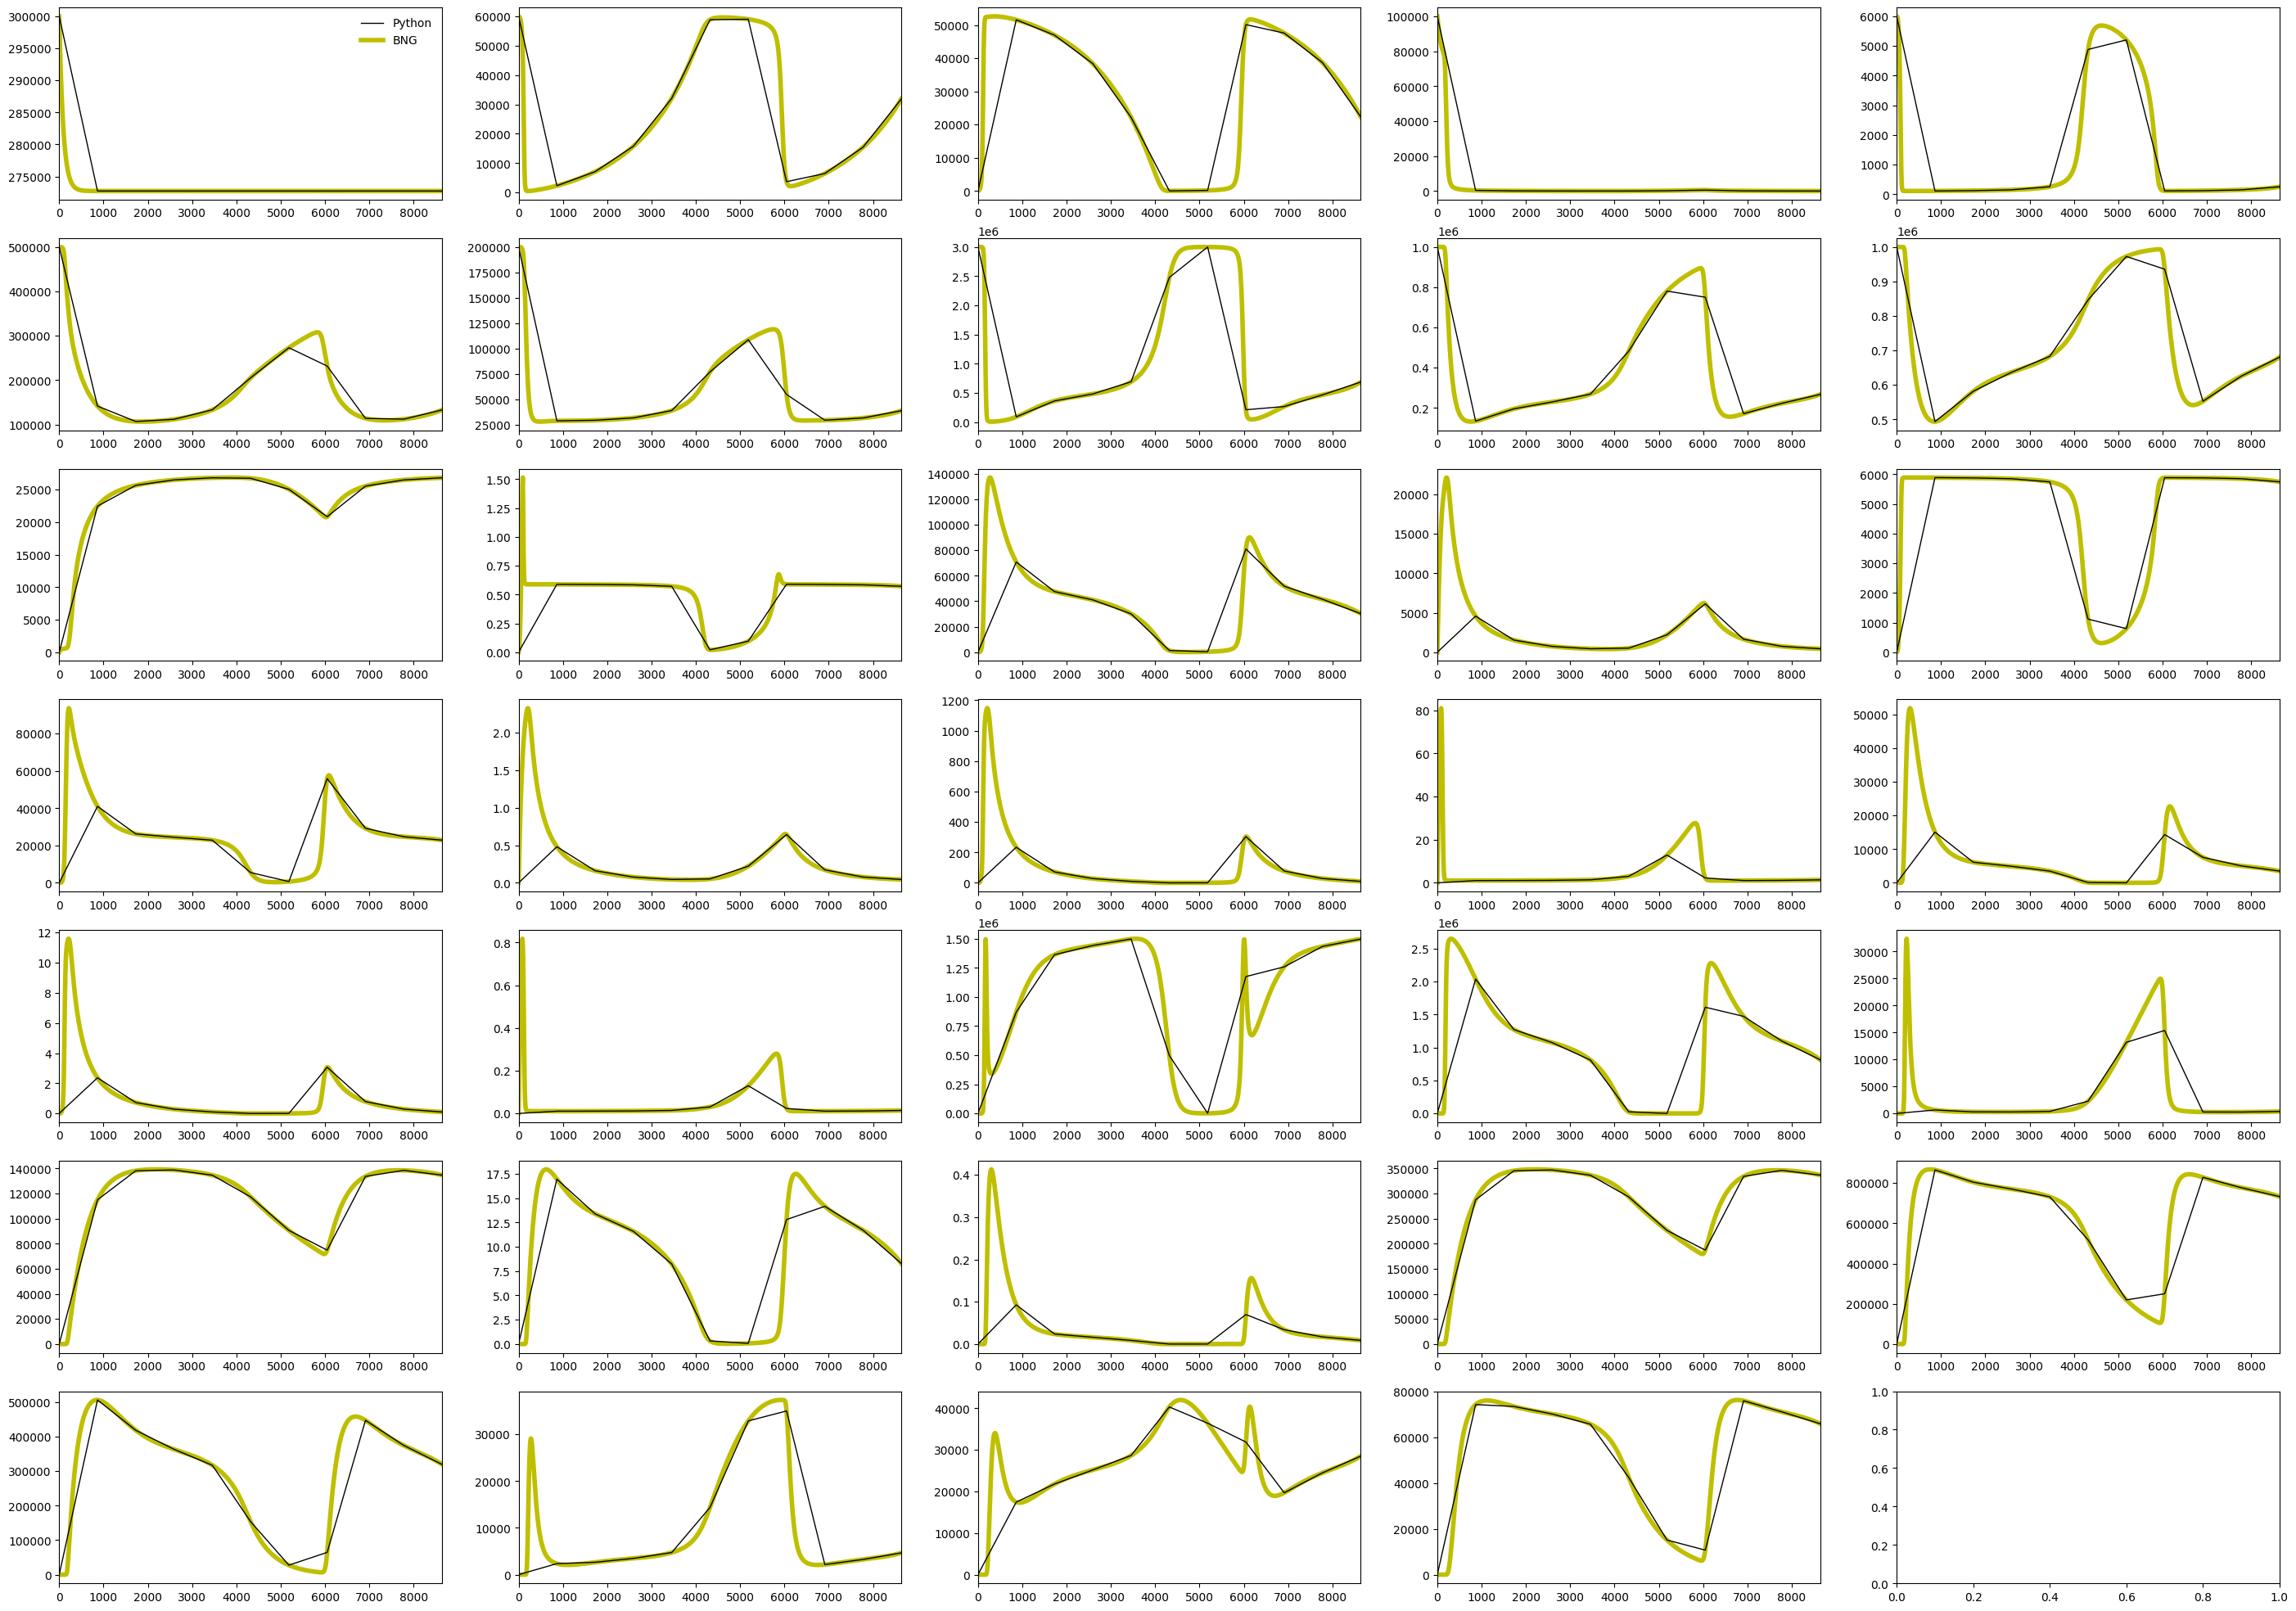

In [14]:
fig,ax = plt.subplots(7,5,figsize=(35,25))

for i in range(7):
    for j in range(5):
        index = i*5+j
        if index<34:
            ax[i][j].plot(tSpan, ys[index,:], zorder=2, lw=1, color='k', label='Python')
            ax[i][j].plot(bng_t, bng_x[index,:],zorder=1, lw=4, color='y', label='BNG')
            ax[i][j].set_xlim(tSpan[[0,-1]])
            if index==0:
                ax[i][j].legend(loc=1, frameon=False)
                

<font color=red> **Apply AD, lo and behold...** </color>

In [ ]:
tic = time()
sensAD = jacrev(xt)(ERKpp_SOS1_FB)
print(f'jitting = {time()-tic}')